### LLM with multiple agents

In [17]:
import os

os.environ["TAVILY_API_KEY"] =  os.getenv("TAVILY_API_KEY")

from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] =  os.getenv("GROQ_API_KEY")
model = ChatGroq(model="qwen/qwen3-32b")



In [18]:
# Google search tool
from langchain_tavily import TavilySearch

travily_search_tool = TavilySearch(
    max_results=5,
    topic="general"
)

travily_search_tool.invoke("Current affairs today ")

{'query': 'Current affairs today',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.currentaffairs.org/',
   'title': 'Home Current Affairs',
   'content': "Enjoy reading interviews with people. See all understand the politics of our time. See all Current Affairs' editorial selections.",
   'score': 0.9814534,
   'raw_content': None},
  {'url': 'https://www.usatoday.com/',
   'title': 'USA TODAY - Breaking News and Latest News Today',
   'content': 'USA TODAY delivers current national and local news, sports, entertainment, finance, technology, and more through award-winning journalism, photos,',
   'score': 0.97821885,
   'raw_content': None},
  {'url': 'https://www.youtube.com/watch?v=Z32twHXqaQ8',
   'title': "The Hindu Newspaper Analysis | 06th April, 2026 | Aastha Ma'am",
   'content': 'currentaffairs #upsc2026 #dailynewsanalysis 1. Kickstart Your UPSC Journey Today! Enroll now and begin your preparation at just 22999/-',
   'score': 0

In [19]:
# Calculator tool
from langchain.tools import tool
import numexpr # pip install numexpr
@tool ("calculator")
def calc(expression: str) -> str:
    """
    Useful for answering math questions. 
    Input should be a mathematical expression that can be evaluated (e.g., '2 + 2', '10 / 3').
    """
    try:
        # Using numexpr for safety over eval()
        result = numexpr.evaluate(expression)
        return str(result)
    except Exception as e:
        return f"Error evaluating expression: {e}"

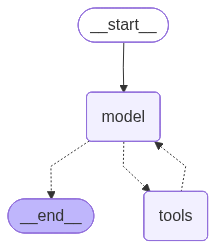

In [20]:
# Create agent
from langchain.agents import create_agent
agent = create_agent(
    model = model,
    tools= [calculator, travily_search_tool],
)
agent

In [26]:
user_input= "Current ai news"

for step in agent.stream(
    {"messages": user_input},
    stream_mode = "values"
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Current ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (m7ycv3sb2)
 Call ID: m7ycv3sb2
  Args:
    include_images: True
    query: AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": ["https://bernardmarr.com/wp-content/uploads/2021/07/Another-Example-Of-How-Artificial-Intelligence-Will-Transform-News-And-Journalism.jpeg", "https://cdn.medicalfuturist.com/wp-content/uploads/2019/06/How-to-Read-News-On-AI.jpg", "https://itchronicles.com/wp-content/uploads/2020/11/where-is-ai-used-1024x683.jpg", "https://itchronicles.com/wp-content/uploads/2020/11/where-is-ai-used.jpg", "https://aimst.edu.my/wp-content/uploads/2023/04/artificial-intelligence-new

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3-32b` in organization `org_01kmdbacybeedr88eh2db2jeg5` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Requested 11867, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}